In [30]:
import gzip
import os
import shutil
import tempfile
import urllib.request
import pandas as pd
import anndata as ad
import decoupler as dc
import numpy as np
import omnipath as op
import networkx as nx
# https://corneto.org
import corneto as cn

In [31]:
##################################################################

df1 = pd.read_csv("/Users/botascan/Desktop/corneto/IFNGR1_IFNG_pathway_DE_results.csv")
df2 = pd.read_csv("/Users/botascan/Desktop/corneto/INSR_INS_pathway_DE_results.csv")
df3 = pd.read_csv("/Users/botascan/Desktop/corneto/STAT1_IFNB_pathway_DE_results.csv")
df4 = pd.read_csv("/Users/botascan/Desktop/corneto/TGFBR2_TGFB1_pathway_DE_results.csv")
df5 = pd.read_csv("/Users/botascan/Desktop/corneto/TNFRSF1A_TNFA_pathway_DE_results.csv")

df1 = df1.set_index('gene_ID').rename_axis(None)
df2 = df2.set_index('gene_ID').rename_axis(None)
df3 = df3.set_index('gene_ID').rename_axis(None)
df4 = df4.set_index('gene_ID').rename_axis(None)
df5 = df5.set_index('gene_ID').rename_axis(None)


receptors = ["IFNGR1", "INSR", "STAT1", "TGFBR2", "TNFRSF1A"]
cell_types = ['A549', 'BXPC3', 'HAP1', 'HT29', 'K562', 'MCF7']

# if single sample
# receptor = receptors[0] # choose receptor
# cell_type = cell_types[0] # choose cell type

# all transcription-factor data
collectri = dc.op.collectri(organism="human")

In [32]:
# Identify the log2FC and p-value columns for these cells
log2_cols = [f'log2FC_{ct}' for ct in cell_types]
p_cols    = [f'p_cell_type{ct}' for ct in cell_types]

#df1[log2_cols]
#df1[p_cols]

# only log2FC values
debloated_df = df1[log2_cols]
data = debloated_df.T
data

,STAT1,WARS,PARP14,RNF213,IRF1,DPYD,LAP3,GBP1,PARP9,GBP4,...,PRAME,POLRMT,DSG3,FBXO10,CRYZL1,MED17,ZNF75A,RSL24D1,EEF1AKMT1,PAFAH1B1
log2FC_A549,-0.826928,-1.475619,-1.095130,-1.272662,-1.501644,-0.518633,-1.432542,-1.383338,-0.782295,-1.925938,...,-0.418558,-0.149492,0.000000,0.030635,0.177691,-0.169614,-0.213910,-0.091171,0.000000,-0.012802
log2FC_BXPC3,-1.167024,-1.742651,-1.326912,-1.240130,-1.480489,-0.630071,-1.267982,-1.851218,-1.145450,-1.614794,...,0.000000,0.000000,-0.007977,0.000000,0.000000,0.156762,-0.061213,0.022208,0.000000,0.011551
log2FC_HAP1,-1.315314,-1.283305,-1.431360,-0.870919,-1.414034,0.000000,-1.351792,-1.891146,-1.436759,-1.428932,...,0.000000,-0.097221,0.000000,-0.180452,-0.027703,-0.149173,-0.163428,0.213855,-0.276991,-0.013027
log2FC_HT29,-1.217859,-1.537470,-1.247932,-1.315691,-1.409362,-1.224602,-1.258586,-1.526319,-1.231235,-1.604511,...,0.000000,0.287115,0.000000,0.000000,0.211635,0.090769,0.000000,0.165056,0.126346,-0.068308
log2FC_K562,-1.611977,-1.106555,-1.200858,-0.201141,-1.856694,0.000000,-0.546498,0.000000,-1.670941,0.000000,...,0.016028,-0.107444,0.000000,0.194684,0.094030,-0.097500,0.132893,-0.139091,0.207930,-0.090887
log2FC_MCF7,-1.420898,-1.531302,-1.537843,-0.683001,-1.462251,-1.184726,-0.542226,-1.635909,-1.403774,-1.322469,...,0.000000,0.000000,0.000000,0.082012,0.078660,-0.054294,0.012753,0.103837,0.033860,0.039953


In [33]:
# calculatae activity score and significance
tf_acts, tf_p = dc.mt.ulm(data=data, net=collectri)

# filter out by p value
msk = (tf_p.T < 0.05).iloc[:,0]
tf_p = tf_p.loc[:,msk]

#tf_acts.T.to_csv(f"TF_acts_{receptor}_{cell_type}")
#tf_p.T.to_csv(f"TF_p_{receptor}_{cell_type}")

In [34]:
# CORNETO / CARNIVAL
from corneto.methods.future import CarnivalFlow

# PKN, all gene network data
pkn = op.interactions.OmniPath.get(databases=["SIGNOR"], genesymbols=True)
pkn = pkn[pkn.consensus_direction == True]

pkn["interaction"] = pkn["is_stimulation"].astype(int) - pkn["is_inhibition"].astype(int)
sel_pkn = pkn[["source_genesymbol", "interaction", "target_genesymbol"]]

In [35]:
from corneto.io import load_graph_from_sif_tuples

G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _,r in sel_pkn.iterrows() if r[1] != 0])

significant_tfs = tf_acts[tf_p <= 0.001].T.dropna().sort_values(by=f"log2FC_{cell_type}", ascending=False)

measurements = significant_tfs.loc[significant_tfs.index.intersection(G.V)].to_dict()[f"log2FC_{cell_type}"]

inputs = {"IFNGR1" : 1}

/var/folders/c2/zy0c1sg140qdkfyn2x4n9tq40000gn/T/ipykernel_57264/2754943364.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _,r in sel_pkn.iterrows() if r[1] != 0])


In [36]:
# create dataset
carnival_data = dict()
for inp, v in inputs.items():
    carnival_data[inp] = dict(value=v, role="input", mapping="vertex")

for out, v in measurements.items():
    carnival_data[out] = dict(value=v, role="output", mapping="vertex")

data = cn.Data.from_cdict({"sample1": carnival_data})
data

Data(n_samples=1, n_feats=[8])

In [37]:
# use CARNIVAL
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data)
P.expr
P.solve(solver="gurobi", max_seconds=60, verbosity=1)

for o in P.objectives:
    print(o.name, "->", o.value)

(CVXPY) Oct 30 02:20:06 PM: Your problem has 10234 variables, 29383 constraints, and 1 parameters.
(CVXPY) Oct 30 02:20:06 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Oct 30 02:20:06 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Oct 30 02:20:06 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Oct 30 02:20:06 PM: Compiling problem (target solver=GUROBI).
(CVXPY) Oct 30 02:20:06 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> GUROBI
(CVXPY) Oct 30 02:20:06 PM: Applying reduction CvxAttr2Constr
(CVXPY) Oct 30 02:20:06 PM: Applying reduction Qp2SymbolicQp
(CVXPY) Oct 30 02:20:06 PM: Applying reduction QpMatrixStuffing
(CVXPY) Oct 30 02:20:06 PM: Applying reduction GUROBI
(CVXPY) Oct 30 02:20:06 PM: Finished problem compilation (took 1.082e-01 seconds).
(CVXPY) Oct 30 02:20:06 PM: (Subsequent compilations of this problem, using the same arguments, 

Unreachable vertices for sample: 0
                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter OutputFlag to value 1


2025-10-30 14:20:06 | [INFO] Set parameter OutputFlag to value 1


Set parameter QCPDual to value 1


2025-10-30 14:20:06 | [INFO] Set parameter QCPDual to value 1


...

Optimal solution found (tolerance 1.00e-04)


2025-10-30 14:20:07 | [INFO] Optimal solution found (tolerance 1.00e-04)


Best objective -1.817725008389e+01, best bound -1.817725008389e+01, gap 0.0000%


2025-10-30 14:20:07 | [INFO] Best objective -1.817725008389e+01, best bound -1.817725008389e+01, gap 0.0000%
(CVXPY) Oct 30 02:20:07 PM: Problem status: optimal
(CVXPY) Oct 30 02:20:07 PM: Optimal value: 3.087e+01
(CVXPY) Oct 30 02:20:07 PM: Compilation took 1.082e-01 seconds
(CVXPY) Oct 30 02:20:07 PM: Solver (including time spent in interface) took 7.407e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
error_sample1_0 -> 17.86518641381394
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 13.0


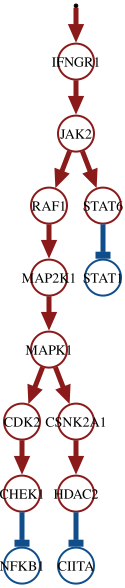

In [38]:
# extract edges
sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
carnival.processed_graph.plot_values(
    vertex_values=P.expr.vertex_value.value,
    edge_values=P.expr.edge_value.value,
    edge_indexes=sol_edges
)

# extract solution Graph
#G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
#G_sol.plot()